## Magnetometer Noise Profiling

In [47]:
import csv
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

path = './imuLog00027.csv'

rows = []
with open(path, newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append({k: float(v) if k not in ('Timestamp', 'Sensor') else v
                     for k, v in row.items()})

print(f'Loaded {len(rows)} samples')

mx = [r['MagX'] for r in rows]
my = [r['MagY'] for r in rows]
mz = [r['MagZ'] for r in rows]
t  = list(range(len(rows)))

Loaded 304 samples


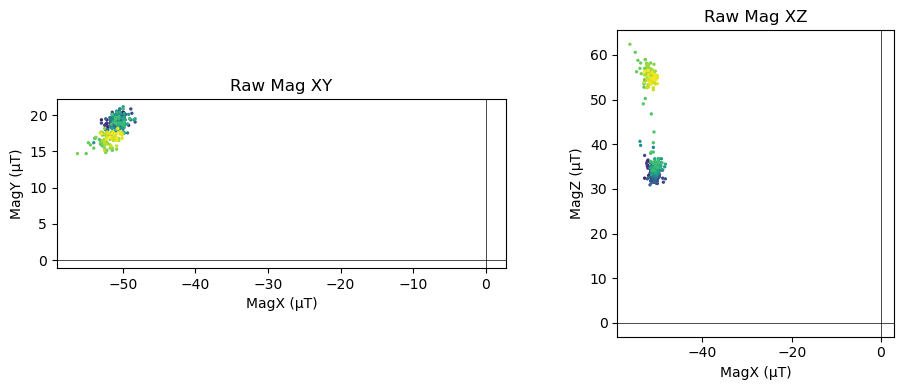

In [48]:
# XY and XZ projections — raw data
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(mx, my, s=2, c=t, cmap='viridis')
axes[0].set_aspect('equal')
axes[0].set_title('Raw Mag XY')
axes[0].set_xlabel('MagX (µT)'); axes[0].set_ylabel('MagY (µT)')
axes[0].axhline(0, color='k', lw=0.5); axes[0].axvline(0, color='k', lw=0.5)

axes[1].scatter(mx, mz, s=2, c=t, cmap='viridis')
axes[1].set_aspect('equal')
axes[1].set_title('Raw Mag XZ')
axes[1].set_xlabel('MagX (µT)'); axes[1].set_ylabel('MagZ (µT)')
axes[1].axhline(0, color='k', lw=0.5); axes[1].axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

In [49]:
## Gyroscope & Accelerometer — extract channels

ax = [r['AccX'] for r in rows]   # mg
ay = [r['AccY'] for r in rows]
az = [r['AccZ'] for r in rows]

gx = [r['GyrX'] for r in rows]   # °/s
gy = [r['GyrY'] for r in rows]
gz = [r['GyrZ'] for r in rows]

acc_mag = np.sqrt(np.array(ax)**2 + np.array(ay)**2 + np.array(az)**2)

print(f'Acc magnitude  — mean: {acc_mag.mean():.1f} mg   std: {acc_mag.std():.2f} mg')
print(f'Gyro X         — mean: {np.mean(gx):.4f} °/s   std: {np.std(gx):.4f} °/s')
print(f'Gyro Y         — mean: {np.mean(gy):.4f} °/s   std: {np.std(gy):.4f} °/s')
print(f'Gyro Z         — mean: {np.mean(gz):.4f} °/s   std: {np.std(gz):.4f} °/s')

Acc magnitude  — mean: 1014.8 mg   std: 26.62 mg
Gyro X         — mean: 0.0463 °/s   std: 1.0350 °/s
Gyro Y         — mean: 0.1255 °/s   std: 1.7110 °/s
Gyro Z         — mean: -0.2152 °/s   std: 1.7606 °/s


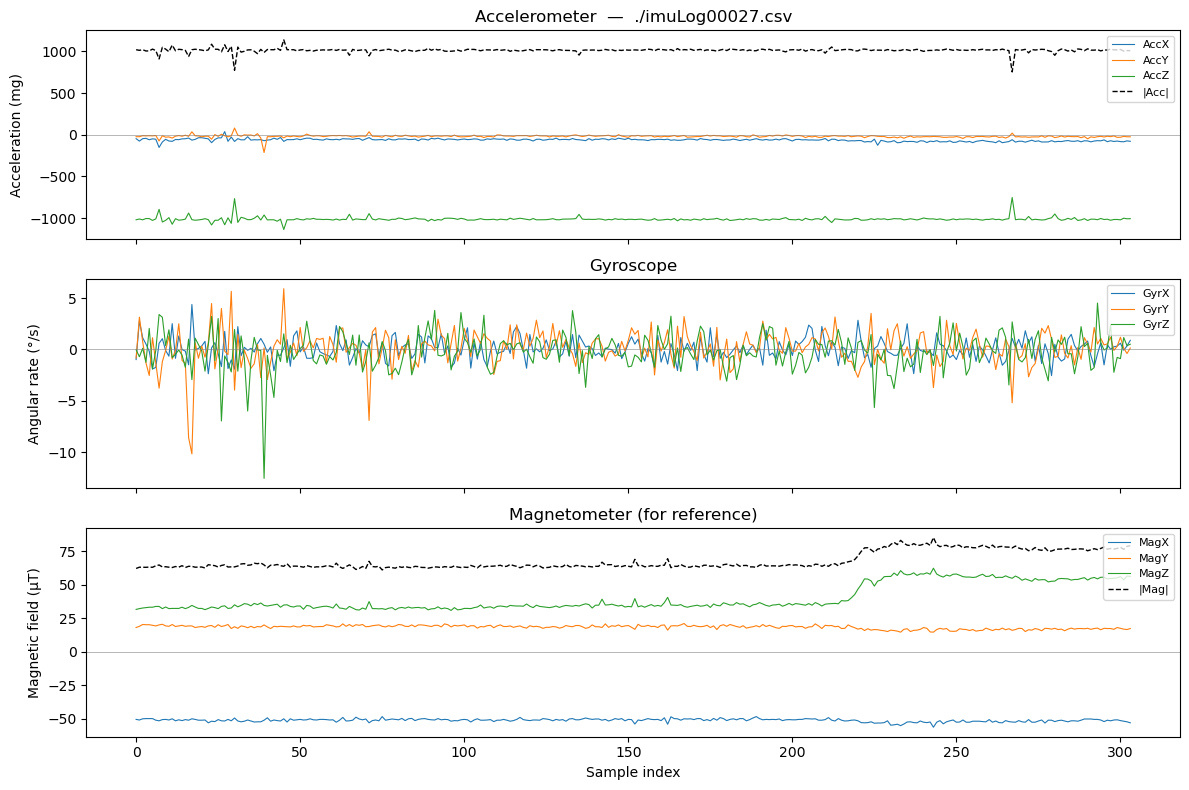

In [50]:
## Gyroscope & Accelerometer — time-series plots

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Accelerometer
axes[0].plot(t, ax, label='AccX', lw=0.8)
axes[0].plot(t, ay, label='AccY', lw=0.8)
axes[0].plot(t, az, label='AccZ', lw=0.8)
axes[0].plot(t, acc_mag, label='|Acc|', color='k', lw=1, ls='--')
axes[0].axhline(0, color='grey', lw=0.4)
axes[0].set_ylabel('Acceleration (mg)')
axes[0].set_title(f'Accelerometer  —  {path}')
axes[0].legend(loc='upper right', fontsize=8)

# Gyroscope
axes[1].plot(t, gx, label='GyrX', lw=0.8)
axes[1].plot(t, gy, label='GyrY', lw=0.8)
axes[1].plot(t, gz, label='GyrZ', lw=0.8)
axes[1].axhline(0, color='grey', lw=0.4)
axes[1].set_ylabel('Angular rate (°/s)')
axes[1].set_title('Gyroscope')
axes[1].legend(loc='upper right', fontsize=8)

# Magnetometer magnitude for reference
mag_mag = np.sqrt(np.array(mx)**2 + np.array(my)**2 + np.array(mz)**2)
axes[2].plot(t, mx, label='MagX', lw=0.8)
axes[2].plot(t, my, label='MagY', lw=0.8)
axes[2].plot(t, mz, label='MagZ', lw=0.8)
axes[2].plot(t, mag_mag, label='|Mag|', color='k', lw=1, ls='--')
axes[2].axhline(0, color='grey', lw=0.4)
axes[2].set_ylabel('Magnetic field (µT)')
axes[2].set_xlabel('Sample index')
axes[2].set_title('Magnetometer (for reference)')
axes[2].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

Window: samples 82 – 142  (60 samples)


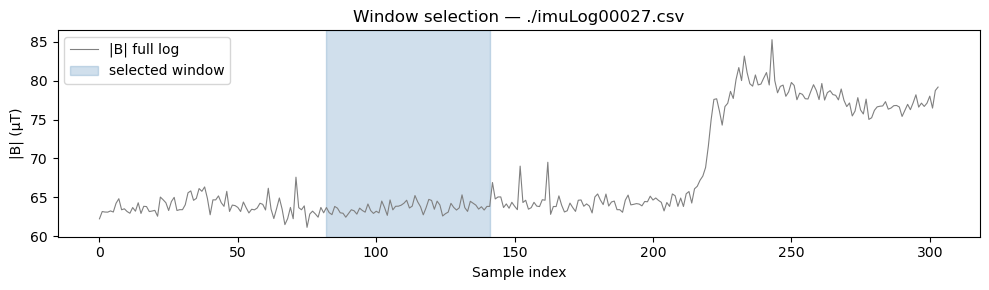

In [51]:
## Time window selection
# Override i_start / i_end manually, or leave as None to auto-detect the flattest window.
i_start = None
i_end   = None

win = 60   # sliding-window width used for auto-detection (samples)

B_all = np.sqrt(np.array(mx)**2 + np.array(my)**2 + np.array(mz)**2)

if i_start is None or i_end is None:
    stds = [B_all[i:i+win].std() for i in range(len(B_all) - win)]
    best = int(np.argmin(stds))
    i_start, i_end = best, best + win

print(f'Window: samples {i_start} – {i_end}  ({i_end - i_start} samples)')

fig, axes_w = plt.subplots(figsize=(10, 3))
axes_w.plot(t, B_all, lw=0.8, color='grey', label='|B| full log')
axes_w.axvspan(i_start, i_end - 1, alpha=0.25, color='steelblue', label='selected window')
axes_w.set_xlabel('Sample index'); axes_w.set_ylabel('|B| (µT)')
axes_w.set_title(f'Window selection — {path}')
axes_w.legend(); plt.tight_layout(); plt.show()

|B| raw  — mean: 63.64 µT   std: 0.644 µT
|B| cal  — mean: 24.06 µT   std: 0.777 µT


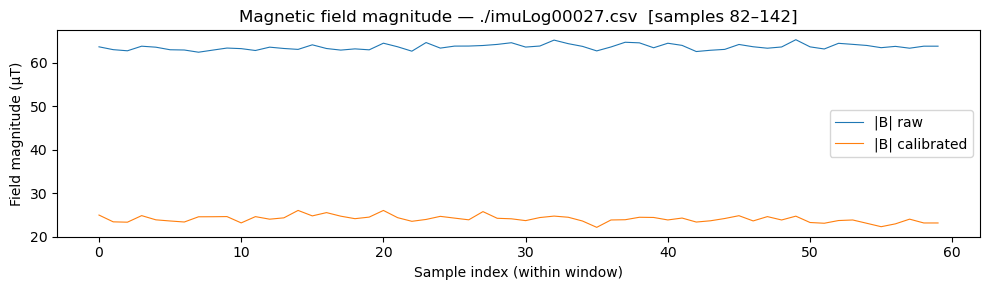

In [52]:
## Magnetic field magnitude

b = np.array([27.975,-20.700,-41.250 ])

# Windowed slices
mx_w = np.array(mx)[i_start:i_end];  my_w = np.array(my)[i_start:i_end];  mz_w = np.array(mz)[i_start:i_end]
mx_c = mx_w + b[0];  my_c = my_w + b[1];  mz_c = mz_w + b[2]
t_w  = list(range(i_end - i_start))

B_raw = np.sqrt(mx_w**2 + my_w**2 + mz_w**2)
B_cal = np.sqrt(mx_c**2 + my_c**2 + mz_c**2)

print(f'|B| raw  — mean: {B_raw.mean():.2f} µT   std: {B_raw.std():.3f} µT')
print(f'|B| cal  — mean: {B_cal.mean():.2f} µT   std: {B_cal.std():.3f} µT')

fig, ax_b = plt.subplots(figsize=(10, 3))
ax_b.plot(t_w, B_raw, label='|B| raw',        lw=0.8)
ax_b.plot(t_w, B_cal, label='|B| calibrated', lw=0.8)
ax_b.set_xlabel('Sample index (within window)')
ax_b.set_ylabel('Field magnitude (µT)')
ax_b.set_title(f'Magnetic field magnitude — {path}  [samples {i_start}–{i_end}]')
ax_b.legend(); plt.tight_layout(); plt.show()

|B| raw  — mean: 63.64 µT   std: 0.644 µT
|B| cal  — mean: 24.06 µT   std: 0.777 µT
|B| soft-iron — mean: 34.15 µT   std: 1.002 µT


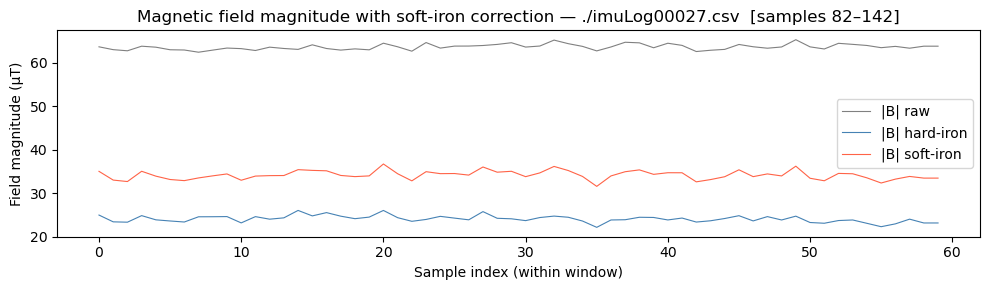

In [53]:
## Soft-iron correction applied to windowed data
# W matrix from magcal_notebook (eigenvector decomposition of hard-iron-corrected covariance)
W = np.array([[ 1.582072, -0.12013,  -0.207156],
              [-0.12013,   1.190786, -0.116498],
              [-0.207156, -0.116498,  0.810077]])

# Apply W to the hard-iron-corrected windowed data
m_hi = np.column_stack([mx_c, my_c, mz_c])   # shape (N, 3)
m_si = (W @ m_hi.T).T                         # shape (N, 3)

B_si = np.linalg.norm(m_si, axis=1)

print(f'|B| raw  — mean: {B_raw.mean():.2f} µT   std: {B_raw.std():.3f} µT')
print(f'|B| cal  — mean: {B_cal.mean():.2f} µT   std: {B_cal.std():.3f} µT')
print(f'|B| soft-iron — mean: {B_si.mean():.2f} µT   std: {B_si.std():.3f} µT')

fig, ax_si = plt.subplots(figsize=(10, 3))
ax_si.plot(t_w, B_raw, label='|B| raw',         lw=0.8, color='grey')
ax_si.plot(t_w, B_cal, label='|B| hard-iron',   lw=0.8, color='steelblue')
ax_si.plot(t_w, B_si,  label='|B| soft-iron',   lw=0.8, color='tomato')
ax_si.set_xlabel('Sample index (within window)')
ax_si.set_ylabel('Field magnitude (µT)')
ax_si.set_title(f'Magnetic field magnitude with soft-iron correction — {path}  [samples {i_start}–{i_end}]')
ax_si.legend(); plt.tight_layout(); plt.show()

The measured value without correction is greater than the actual magnetic field in San Diego, but with correction the value is considerably lower. However, this is not totally surprising, since without soft-iron calibration the value can be estimated as lower. Adding in soft-iron calibration gets the field magnitude to 34 uT, which is better than hard iron alone but still undershooting. It's likely that the soft-iron calibration isn't perfect because I was translating the magnetometer in 3d space when collecting the measurements, and sometimes it was too close to the laptop. Re-doing this calibration outdoors would produce a far more accurate reading.

Heading raw       — mean: 159.4°   std: 0.77°
Heading cal       — mean: 184.1°   std: 1.90°
Heading soft-iron — mean: 177.2°   std: 1.59°


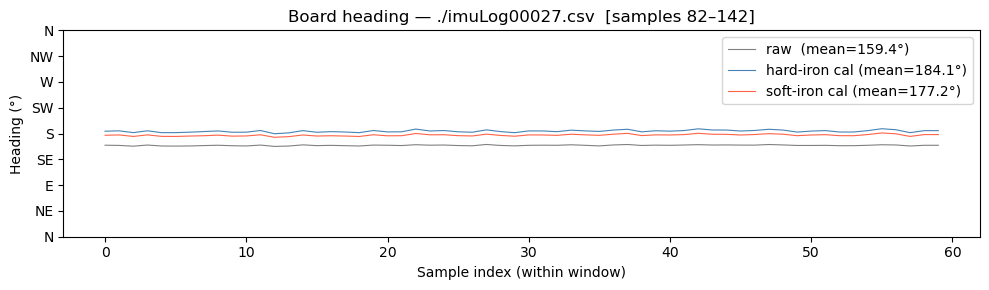

In [54]:
## Board heading from atan2(MagY, MagX)
# Assumes board is flat (no tilt compensation). Uses windowed data from above.

heading_raw = np.degrees(np.arctan2(my_w, mx_w)) % 360
heading_cal = np.degrees(np.arctan2(my_c, mx_c)) % 360
heading_si  = np.degrees(np.arctan2(m_si[:, 1], m_si[:, 0])) % 360

print(f'Heading raw       — mean: {heading_raw.mean():.1f}°   std: {heading_raw.std():.2f}°')
print(f'Heading cal       — mean: {heading_cal.mean():.1f}°   std: {heading_cal.std():.2f}°')
print(f'Heading soft-iron — mean: {heading_si.mean():.1f}°   std: {heading_si.std():.2f}°')

fig, ax_h = plt.subplots(figsize=(10, 3))
ax_h.plot(t_w, heading_raw, lw=0.8, color='grey',      label=f'raw  (mean={heading_raw.mean():.1f}°)')
ax_h.plot(t_w, heading_cal, lw=0.8, color='steelblue', label=f'hard-iron cal (mean={heading_cal.mean():.1f}°)')
ax_h.plot(t_w, heading_si,  lw=0.8, color='tomato',    label=f'soft-iron cal (mean={heading_si.mean():.1f}°)')
ax_h.set_xlabel('Sample index (within window)')
ax_h.set_ylabel('Heading (°)')
ax_h.set_title(f'Board heading — {path}  [samples {i_start}–{i_end}]')
ax_h.set_ylim(0, 360)
ax_h.set_yticks([0, 45, 90, 135, 180, 225, 270, 315, 360])
ax_h.set_yticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW', 'N'])
ax_h.legend(); plt.tight_layout(); plt.show()

We probably had the magnetometer backwards from north accidentally, so this orientation makes sense! The hard-iron calibration is definitely a substantial improvement.

---
## Magnetometer Noise Analysis (RMS)

Using the flat-window slice selected above, subtract the per-axis DC mean to isolate the
noise residual and quantify it as RMS (σ) — the same approach used for the accelerometer
static test.

For a digital sensor sampled at $f_s$, the datasheet noise density prediction is

$$\sigma_{predicted} = NSD \times \sqrt{f_s / 2}$$

The MMC5983MA magnetometer on the OLA specifies a per-axis RMS noise of roughly
**0.4 mGauss ≈ 0.04 µT** at its default bandwidth setting; this is used as the reference
line in the histograms below.

Mean mag sample rate: 9.96 Hz   (duration 30.4 s)
MagX: measured RMS = 0.6549 µT  |  datasheet = 0.0400 µT  |  ratio = 16.4
MagY: measured RMS = 0.7462 µT  |  datasheet = 0.0400 µT  |  ratio = 18.7
MagZ: measured RMS = 1.0798 µT  |  datasheet = 0.0400 µT  |  ratio = 27.0

|B| raw        : RMS = 0.6441 µT
|B| hard-iron  : RMS = 0.7769 µT
|B| soft-iron  : RMS = 1.0018 µT


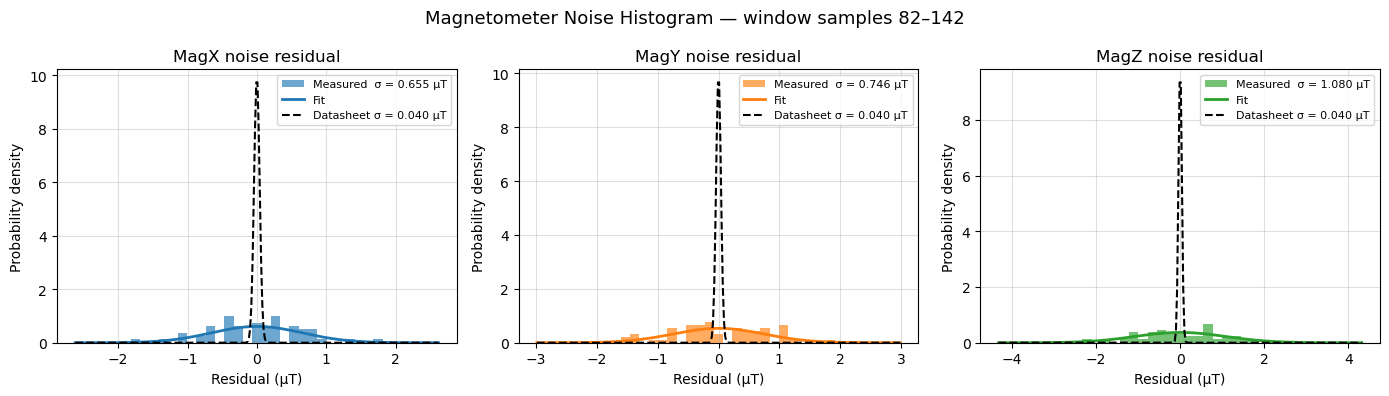

In [45]:
# ── Noise histogram with expected vs. measured RMS (magnetometer) ────────────
from datetime import datetime

# Effective sample rate from CSV timestamps
ts = [datetime.strptime(r['Timestamp'], '%Y/%m/%d %H:%M:%S.%f') for r in rows]
duration = (ts[-1] - ts[0]).total_seconds()
fs_mag = (len(ts) - 1) / duration if duration > 0 else float('nan')
print(f'Mean mag sample rate: {fs_mag:.2f} Hz   (duration {duration:.1f} s)')

# Datasheet reference (MMC5983MA): ~0.4 mGauss RMS per axis ≈ 0.04 µT
sigma_expected = 0.04   # µT, per axis

axes_labels = ['X', 'Y', 'Z']
axes_data   = [mx_w, my_w, mz_w]
colors      = ['tab:blue', 'tab:orange', 'tab:green']

fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for i, (lbl, data, col) in enumerate(zip(axes_labels, axes_data, colors)):
    residual = data - np.mean(data)
    sigma_meas = np.std(residual)

    lim = max(4 * sigma_expected, 4 * sigma_meas)
    bins = np.linspace(-lim, lim, 40)
    axs[i].hist(residual, bins=bins, color=col, alpha=0.65, density=True,
                label=f'Measured  σ = {sigma_meas:.3f} µT')

    x_gauss = np.linspace(bins[0], bins[-1], 300)
    gauss_meas     = (1/(sigma_meas    * np.sqrt(2*np.pi))) * np.exp(-0.5*(x_gauss/sigma_meas   )**2)
    gauss_expected = (1/(sigma_expected* np.sqrt(2*np.pi))) * np.exp(-0.5*(x_gauss/sigma_expected)**2)

    axs[i].plot(x_gauss, gauss_meas,     col,  lw=2, label='Fit')
    axs[i].plot(x_gauss, gauss_expected, 'k--', lw=1.5,
                label=f'Datasheet σ = {sigma_expected:.3f} µT')

    axs[i].set_title(f'Mag{lbl} noise residual')
    axs[i].set_xlabel('Residual (µT)')
    axs[i].set_ylabel('Probability density')
    axs[i].legend(fontsize=8)
    axs[i].grid(True, alpha=0.4)
    print(f'Mag{lbl}: measured RMS = {sigma_meas:.4f} µT  |  '
          f'datasheet = {sigma_expected:.4f} µT  |  '
          f'ratio = {sigma_meas/sigma_expected:.1f}')

# |B| noise (raw, hard-iron, soft-iron) — subtract mean to isolate residual
print()
for name, B in [('|B| raw        ', B_raw),
                ('|B| hard-iron  ', B_cal),
                ('|B| soft-iron  ', B_si)]:
    print(f'{name}: RMS = {np.std(B - np.mean(B)):.4f} µT')

fig.suptitle(f'Magnetometer Noise Histogram — window samples {i_start}–{i_end}', fontsize=13)
plt.tight_layout()
plt.show()

The measured per-axis RMS sits well above the MMC5983MA datasheet spec of ~0.04 µT, just
as the accelerometer's measured σ came in well above its datasheet value. Even in the
flattest window the "static" segment is not truly field-free: slow drift of the ambient
field and coupling from nearby electronics (laptop, bench wiring) inflate the residual.
The soft-iron |B| RMS is also larger than the raw |B| RMS, which is expected — the
W matrix stretches the noisier axes when it re-shapes the field-magnitude sphere. Repeating
the static log outdoors, away from electronics, would be expected to bring the per-axis σ
much closer to the datasheet value.

### Minimum Resolvable Heading Angle

Propagating the per-axis noise σ through $\theta = \operatorname{atan2}(M_y, M_x)$ with
independent, equal-σ errors gives

$$\sigma_\theta \;=\; \frac{\sigma_M}{|H|}$$

where $|H| = \sqrt{\langle M_x\rangle^2 + \langle M_y\rangle^2}$ is the horizontal field
magnitude. This σ is the 1-σ heading uncertainty — the smallest angular change we can
reliably distinguish from noise is on the order of $\sigma_\theta$, with a conservative
"just detectable" threshold of ~$3\sigma_\theta$.

In [46]:
# ── Minimum resolvable heading angle from measured noise ─────────────────────
# Per-axis RMS on the flat window
sigma_x = np.std(mx_w - np.mean(mx_w))
sigma_y = np.std(my_w - np.mean(my_w))
sigma_z = np.std(mz_w - np.mean(mz_w))
sigma_h = 0.5 * (sigma_x + sigma_y)   # average horizontal-plane σ

# Horizontal field magnitudes (raw vs. hard-iron corrected)
H_raw = np.sqrt(np.mean(mx_w)**2 + np.mean(my_w)**2)
H_cal = np.sqrt(np.mean(mx_c)**2 + np.mean(my_c)**2)

# 1-σ heading uncertainty (degrees)
sigma_theta_raw = np.degrees(sigma_h / H_raw)
sigma_theta_cal = np.degrees(sigma_h / H_cal)

# Full 3-axis angular resolution: σ/|B| with the mean per-axis σ
sigma_B = (sigma_x + sigma_y + sigma_z) / 3
sigma_3d = np.degrees(sigma_B / B_cal.mean())

# Datasheet-limited heading uncertainty for comparison
sigma_theta_datasheet = np.degrees(0.04 / H_cal)

print(f'Per-axis RMS     : σx={sigma_x:.3f} µT   σy={sigma_y:.3f} µT   σz={sigma_z:.3f} µT')
print(f'Horizontal field : |H| raw = {H_raw:.2f} µT   |H| hard-iron = {H_cal:.2f} µT')
print()
print(f'1-σ heading uncertainty (raw axes)        : σθ ≈ {sigma_theta_raw:.2f}°')
print(f'1-σ heading uncertainty (hard-iron cal)   : σθ ≈ {sigma_theta_cal:.2f}°')
print(f'1-σ 3-axis angular resolution             : σ  ≈ {sigma_3d:.2f}°')
print(f'→ smallest reliably resolvable change     : ~3σ = {3*sigma_theta_cal:.2f}°')
print()
print(f'Datasheet-limited heading σ (σ_M=0.04 µT) : {sigma_theta_datasheet:.3f}°')
print()
print(f'Sanity check — observed heading scatter in the flat window:')
print(f'  heading_raw std = {heading_raw.std():.2f}°   heading_cal std = {heading_cal.std():.2f}°')

Per-axis RMS     : σx=0.655 µT   σy=0.746 µT   σz=1.080 µT
Horizontal field : |H| raw = 54.11 µT   |H| hard-iron = 22.73 µT

1-σ heading uncertainty (raw axes)        : σθ ≈ 0.74°
1-σ heading uncertainty (hard-iron cal)   : σθ ≈ 1.77°
1-σ 3-axis angular resolution             : σ  ≈ 1.97°
→ smallest reliably resolvable change     : ~3σ = 5.30°

Datasheet-limited heading σ (σ_M=0.04 µT) : 0.101°

Sanity check — observed heading scatter in the flat window:
  heading_raw std = 0.77°   heading_cal std = 1.90°
